# **Модель, которая предсказывает пол убийцы**

In [1]:
import re
import ast
from collections import defaultdict

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    MultiLabelBinarizer,
    OneHotEncoder,
    StandardScaler
)

import optuna
from optuna import create_study
from optuna.importance import get_param_importances

from catboost import CatBoostClassifier

In [2]:
df = pd.read_csv('df_labeled_all_final_25.csv')

In [3]:
def replace_different(value):
    if pd.isna(value): 
        return value
    parts = value.split(", ") if ", " in value else [value]
    parts = ["другое место" if part == "другое" else part for part in parts]
    return ", ".join(parts)

df['location'] = df['location'].apply(replace_different)

In [5]:
df["location"]


0              рабочая зона, уличное пространство
1        общественное место, уличное пространство
2                                 жилое помещение
3                            уличное пространство
4                                 жилое помещение
                           ...                   
37564                             жилое помещение
37565                             жилое помещение
37566                             жилое помещение
37567                             жилое помещение
37568                        уличное пространство
Name: location, Length: 37569, dtype: object

In [6]:
df['motive'] = df['motive'].replace('другое', 'другой мотив')
df['motive'] = df['motive'].replace('корысть, другое', 'корысть, другой мотив')
df['motive'] = df['motive'].replace('личная неприязнь, другое', 'личная неприязнь, другой мотив')
df['motive'].value_counts()


motive
личная неприязнь                          34688
корысть, личная неприязнь                   935
корысть                                     610
другой мотив                                468
личная неприязнь, ревность                  310
                                          ...  
личная неприязнь, оскорбление, насилие        1
ссора, личная неприязнь                       1
ревность, месть, личная неприязнь             1
аморальное поведение потерпевшего             1
аморальность, противоправность                1
Name: count, Length: 117, dtype: int64

In [7]:
df['location'] = df['location'].replace('другое', 'другая локация')

In [8]:
print(df.columns)

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'method', 'motive', 'location', 'prison_term', 'many_victims', 'year',
       'season', 'attempt', 'victim_child_or_helpless', 'cruel',
       'region_name'],
      dtype='object')


In [4]:
motive_mapping = {
    'личная неприязнь': 'личная неприязнь',
    'неприязнь': 'личная неприязнь',
    'ссора': 'личная неприязнь',
    'обида': 'личная неприязнь',
    'злость': 'личная неприязнь',
    'агрессия': 'личная неприязнь',
    'ярость': 'личная неприязнь',
    'раздражение': 'личная неприязнь',
    'оскорбление': 'личная неприязнь',
    'ненависть': 'личная неприязнь',

    'ревность': 'ревность',
    'зависть': 'ревность',

    'месть': 'месть',

    'корысть': 'корысть',
    'имущество': 'корысть',
    'ограбление': 'корысть',
    'хищение': 'корысть',
    'кража': 'корысть',
    'деньги': 'корысть',
    'личное обогащение': 'корысть',
    'наследство': 'корысть',
    'вымогательство': 'корысть',

    'алкоголь': 'алкоголь/наркотики',
    'алкогольное опьянение': 'алкоголь/наркотики',
    'наркотики': 'алкоголь/наркотики',

    'аморальное поведение': 'аморальность',
    'аморальность': 'аморальность',
    'противоправное поведение': 'аморальность',
    'унижение': 'аморальность',
    'оскорбления': 'аморальность',

    'насилие': 'насилие',
    'половое насилие': 'насилие',
    'сексуальное домогательство': 'насилие',
    'попытка изнасилования': 'насилие',

    'неизвестно': 'прочее',
    'сострадание': 'прочее',
    'страх': 'прочее',
    'жалость': 'прочее',
    'самозащита': 'прочее',
    'защита': 'прочее',
}

def map_multiple_motives(text):
    text = str(text).lower()
    matched_categories = set()
    for keyword, group in motive_mapping.items():
        if keyword in text:
            matched_categories.add(group)
    return ', '.join(sorted(matched_categories)) if matched_categories else 'прочее'

df.loc[:, 'motive'] = df['motive'].apply(map_multiple_motives)
df['motive'].value_counts()

motive
личная неприязнь                        34770
корысть, личная неприязнь                1036
корысть                                   625
прочее                                    510
личная неприязнь, ревность                351
ревность                                  135
личная неприязнь, месть                    74
аморальность, личная неприязнь             16
месть                                      12
аморальность                               12
корысть, месть                              7
алкоголь/наркотики, личная неприязнь        4
личная неприязнь, насилие                   4
корысть, личная неприязнь, месть            3
личная неприязнь, месть, ревность           3
личная неприязнь, прочее                    3
аморальность, месть                         1
корысть, ревность                           1
аморальность, насилие                       1
месть, ревность                             1
Name: count, dtype: int64

In [10]:
if "другое" in df["motive"].values:
    print("Значение 'другое' найдено в столбце MOTIVE")


In [11]:
print(df["gender_accused"])

0        1
1        1
2        1
3        0
4        1
        ..
37564    1
37565    1
37566    1
37567    1
37568    1
Name: gender_accused, Length: 37569, dtype: int64


In [6]:
categorical = ['judge', 'decision','season', 'region_name','year']
#numeric = ['prison_term']
multilabel = ['method', 'motive', 'location']
other = ['gender_accused', 'prior_convictions', 'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim', 'many_victims', 'attempt', 'victim_child_or_helpless', 'cruel']

In [7]:
selected_columns = ['alcohol', 'prior_convictions', 'precrime_argument', 'has_woman_victim', 'has_man_victim', 'many_victims','victim_child_or_helpless', 'cruel', 'attempt']
df_temp = df[selected_columns].copy()
df_temp = df_temp.apply(pd.to_numeric, errors='coerce')
gender_analysis = df.groupby('gender_accused')[selected_columns].mean()
gender_analysis = gender_analysis.T.reset_index()
gender_analysis.columns = ['Признак', 'Женщины (0)', 'Мужчины (1)']
print(gender_analysis)


                    Признак  Женщины (0)  Мужчины (1)
0                   alcohol     0.900184     0.831233
1         prior_convictions     0.095135     0.161739
2         precrime_argument     0.949005     0.914050
3          has_woman_victim     0.114028     0.358237
4            has_man_victim     0.891323     0.769628
5              many_victims     0.010199     0.062967
6  victim_child_or_helpless     0.017054     0.016367
7                     cruel     0.011704     0.019849
8                   attempt     0.156830     0.237875


In [8]:
for col in multilabel:
    df[col] = df[col].str.split(", ")
    mlb = MultiLabelBinarizer()
    col_binarized = mlb.fit_transform(df[col])
    col_df = pd.DataFrame(col_binarized, columns=mlb.classes_)
    col_df.index = df.index
    df = pd.concat([df, col_df], axis=1).drop(col, axis=1)

In [9]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'prison_term', 'many_victims', 'year', 'season', 'attempt',
       'victim_child_or_helpless', 'cruel', 'region_name', 'другое',
       'огнестрельное оружие', 'тяжелые предметы', 'удушение',
       'физическое воздействие', 'холодное оружие', 'алкоголь/наркотики',
       'аморальность', 'корысть', 'личная неприязнь', 'месть', 'насилие',
       'прочее', 'ревность', 'другое место', 'жилое помещение',
       'общественное место', 'общественный транспорт',
       'подъезд и прилегающие зоны', 'рабочая зона', 'уличное пространство'],
      dtype='object')

In [10]:
other = [x for x in other if x != "gender_accused"]

C:\Users\tikho\AppData\Local\Temp\ipykernel_9824\3741080457.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='pastel')


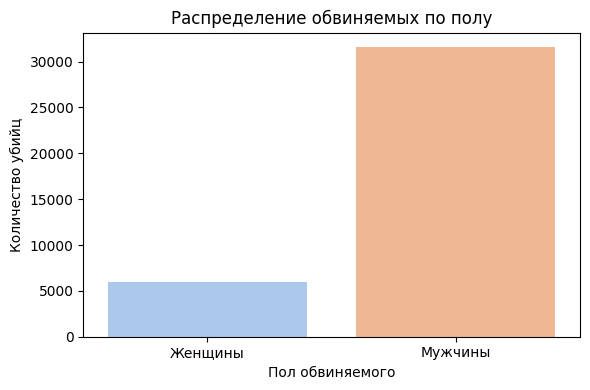

In [11]:
gender_counts = df['gender_accused'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
sns.barplot(x=gender_counts.index, y=gender_counts.values, palette='pastel')
plt.xticks([0, 1], ['Женщины', 'Мужчины'])
plt.title('Распределение обвиняемых по полу')
plt.xlabel('Пол обвиняемого')
plt.ylabel('Количество убийц')
plt.tight_layout()
plt.show()

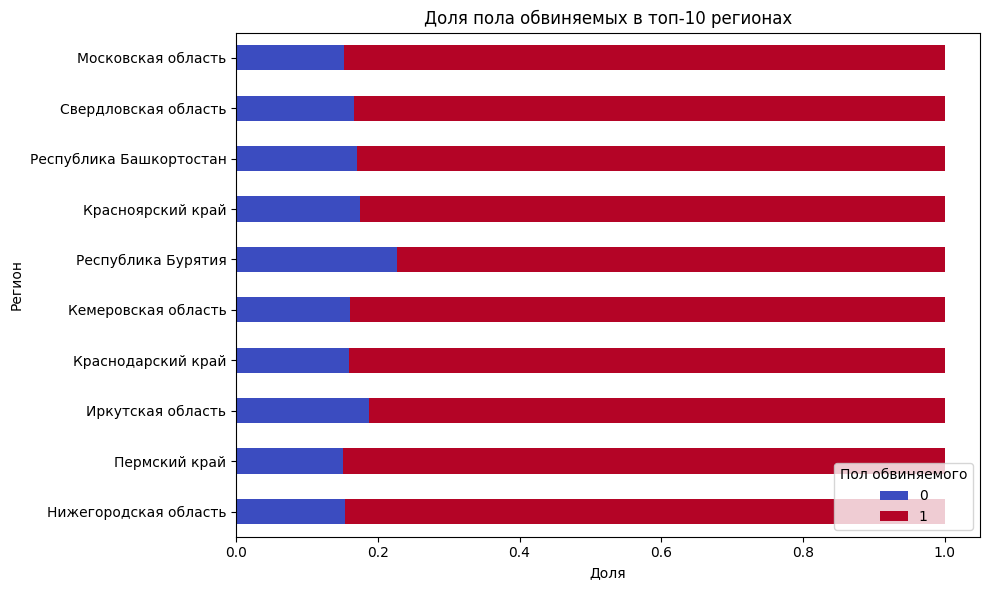

In [12]:
def plot_top_regions_by_gender_share(df, gender_col='gender_accused', region_col='region_name', top_n=10):
    region_counts = pd.crosstab(df[region_col], df[gender_col])
    region_counts['total'] = region_counts.sum(axis=1)
    top_regions = region_counts.sort_values('total', ascending=False).head(top_n).drop(columns='total')
    region_percent = top_regions.div(top_regions.sum(axis=1), axis=0)
    region_percent.plot(kind='barh', stacked=True, colormap='coolwarm', figsize=(10, 6))
    plt.title(f'Доля пола обвиняемых в топ-{top_n} регионах')
    plt.xlabel('Доля')
    plt.ylabel('Регион')
    plt.legend(title='Пол обвиняемого', loc='lower right')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

plot_top_regions_by_gender_share(df)


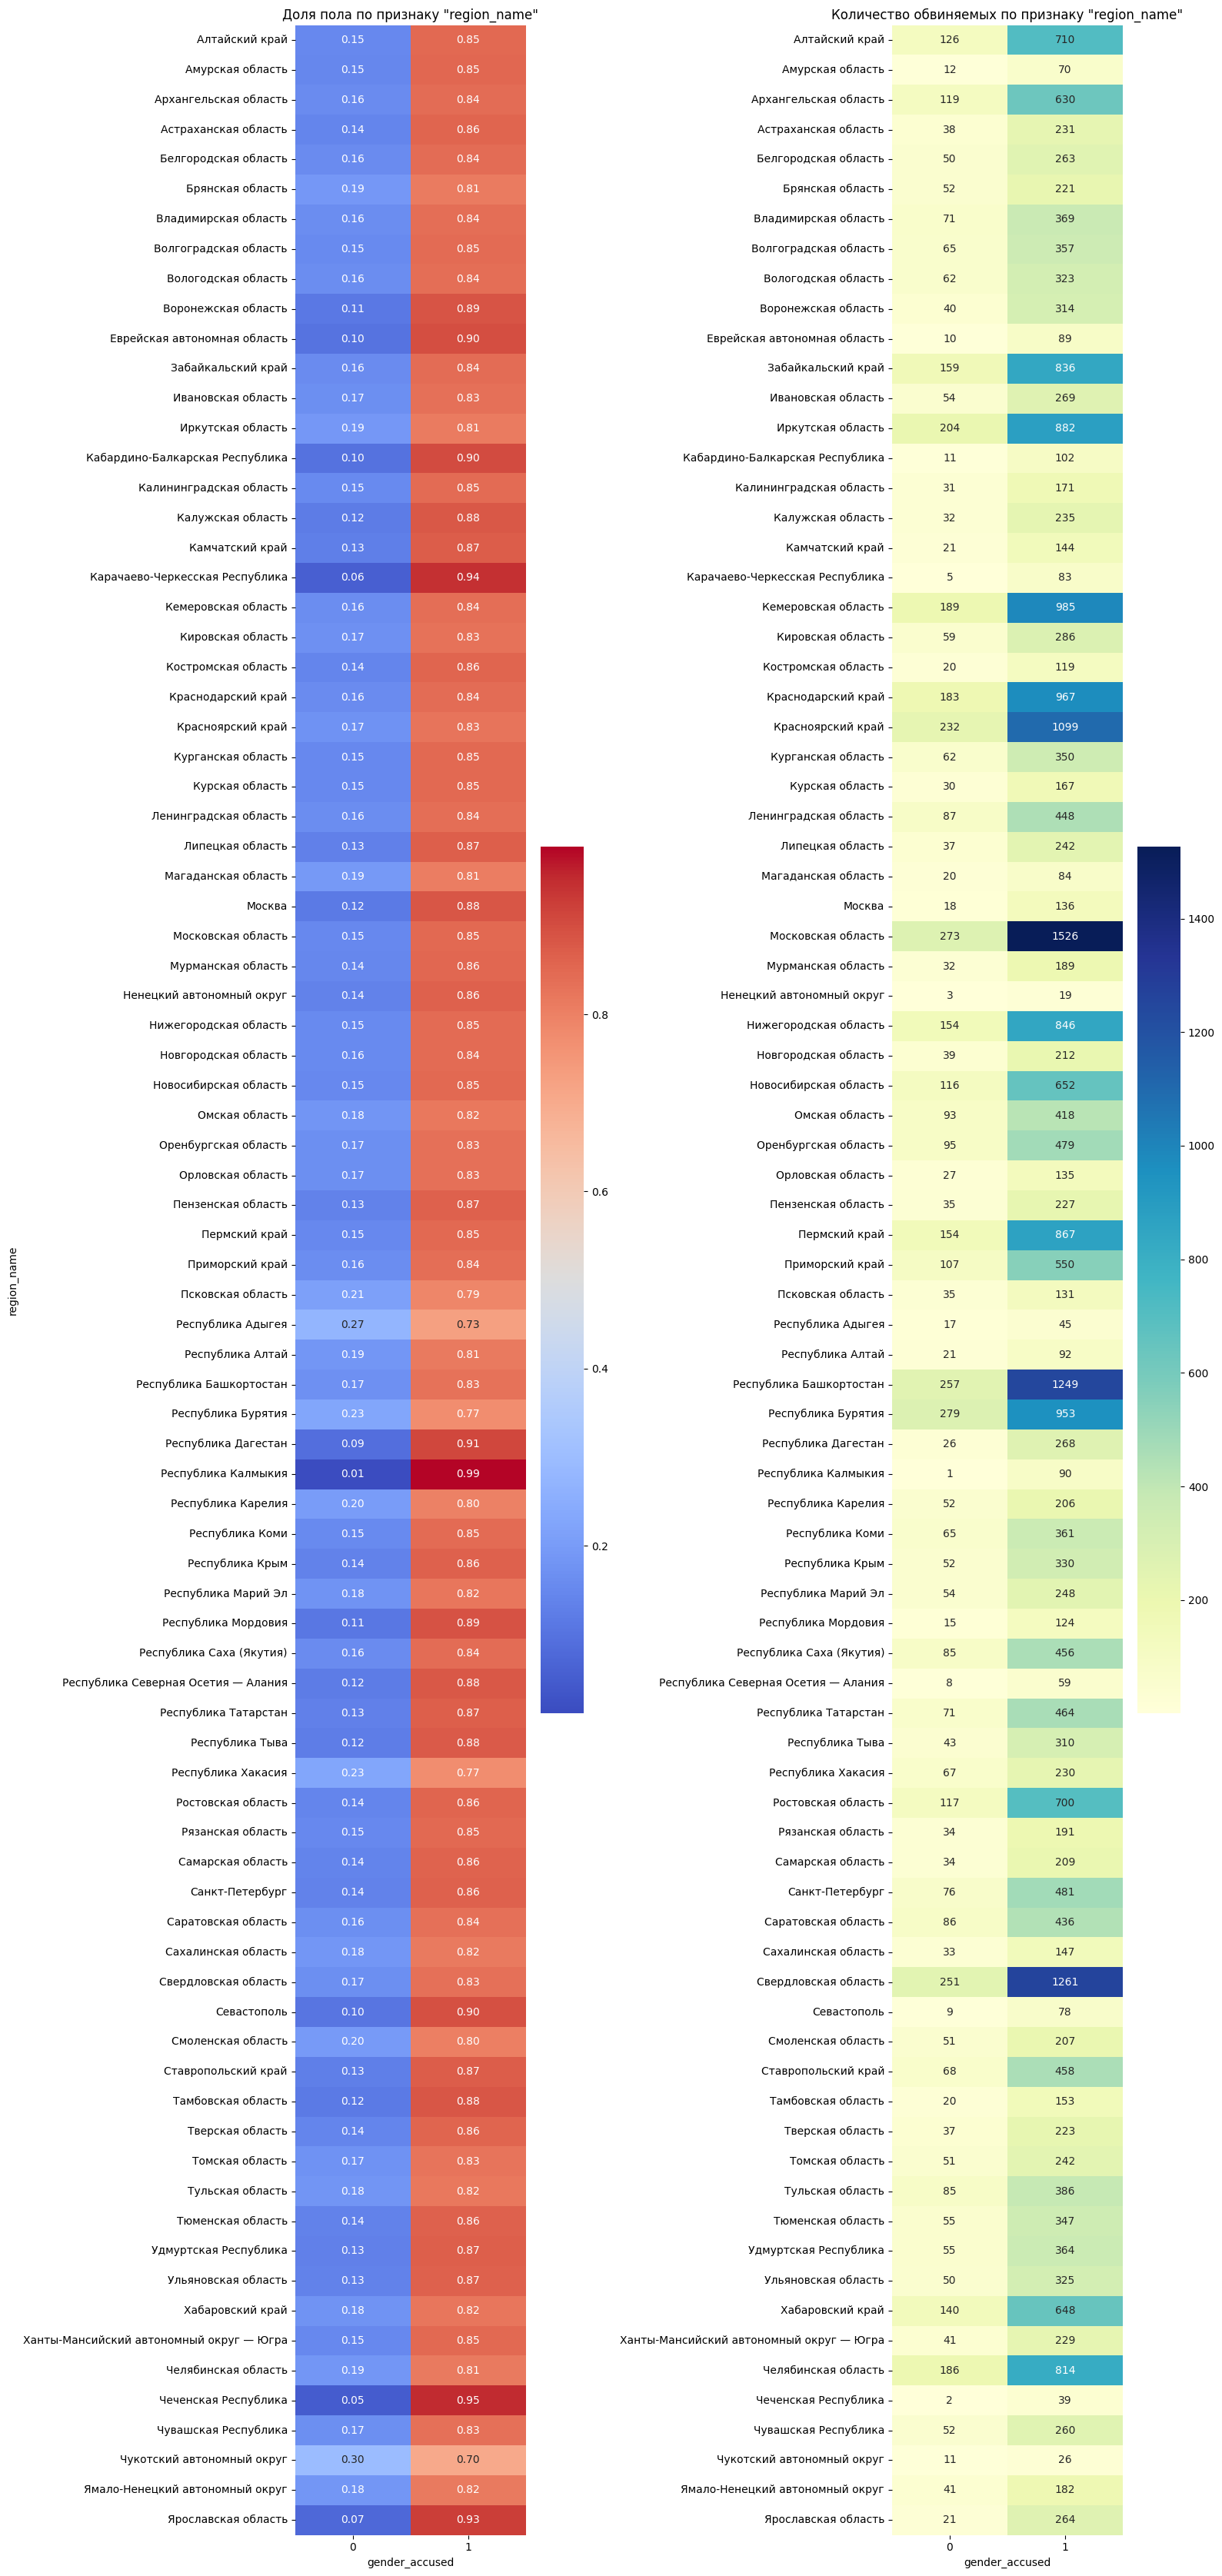

In [13]:
def plot_heatmap_gender_by_category(df, feature):
    pivot_percent = pd.crosstab(df[feature], df['gender_accused'], normalize='index')
    pivot_count = pd.crosstab(df[feature], df['gender_accused'])
    fig, axes = plt.subplots(1, 2, figsize=(16, max(4, len(pivot_percent) * 0.4)))
    sns.heatmap(pivot_percent, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0])
    axes[0].set_title(f'Доля пола по признаку "{feature}"')
    axes[0].set_xlabel('gender_accused')
    axes[0].set_ylabel(feature)
    sns.heatmap(pivot_count, annot=True, cmap='YlGnBu', fmt='d', ax=axes[1])
    axes[1].set_title(f'Количество обвиняемых по признаку "{feature}"')
    axes[1].set_xlabel('gender_accused')
    axes[1].set_ylabel("")
    plt.tight_layout()
    plt.show()
plot_heatmap_gender_by_category(df,"region_name")

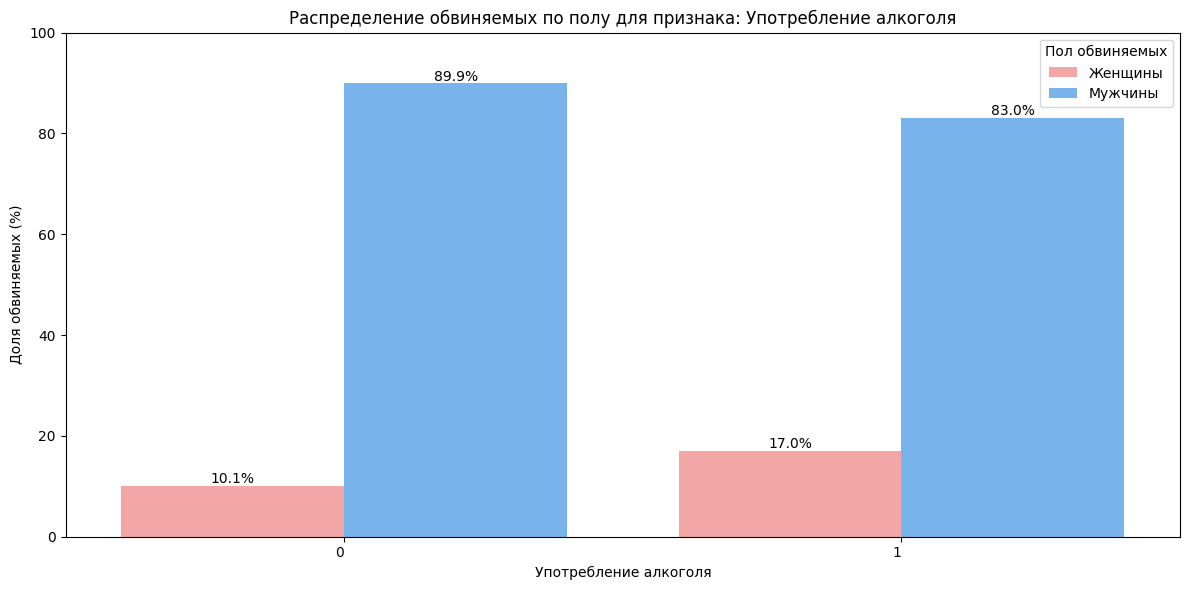

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_gender_share_by_feature(df, feature_col, gender_col='gender_accused', feature_name='Признак'):
    gender_distribution = (
        df.groupby([feature_col, gender_col])
        .size()
        .reset_index(name='count')
    )
    total_per_feature = gender_distribution.groupby(feature_col)['count'].transform('sum')
    gender_distribution['share'] = (gender_distribution['count'] / total_per_feature * 100).round(1)
    gender_distribution['gender_label'] = gender_distribution[gender_col].map({0: 'Женщины', 1: 'Мужчины'})
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(
        data=gender_distribution, 
        x=feature_col, 
        y='share', 
        hue='gender_label',
        palette=['#ff9999', '#66b3ff']
    )
    for p in ax.patches:
        height = p.get_height()
        if height >= 1:
            ax.annotate(
                f'{height:.1f}%', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', 
                va='center', 
                xytext=(0, 5), 
                textcoords='offset points'
            )

    plt.ylabel('Доля обвиняемых (%)')
    plt.xlabel(feature_name)
    plt.title(f'Распределение обвиняемых по полу для признака: {feature_name}')
    plt.legend(title='Пол обвиняемых')
    plt.xticks(rotation=0, ha='right')
    plt.ylim(0, 100)
    plt.grid(axis='y', linestyle='--', alpha=0)
    plt.tight_layout()
    plt.show()

plot_gender_share_by_feature(df, 'alcohol', feature_name='Употребление алкоголя')

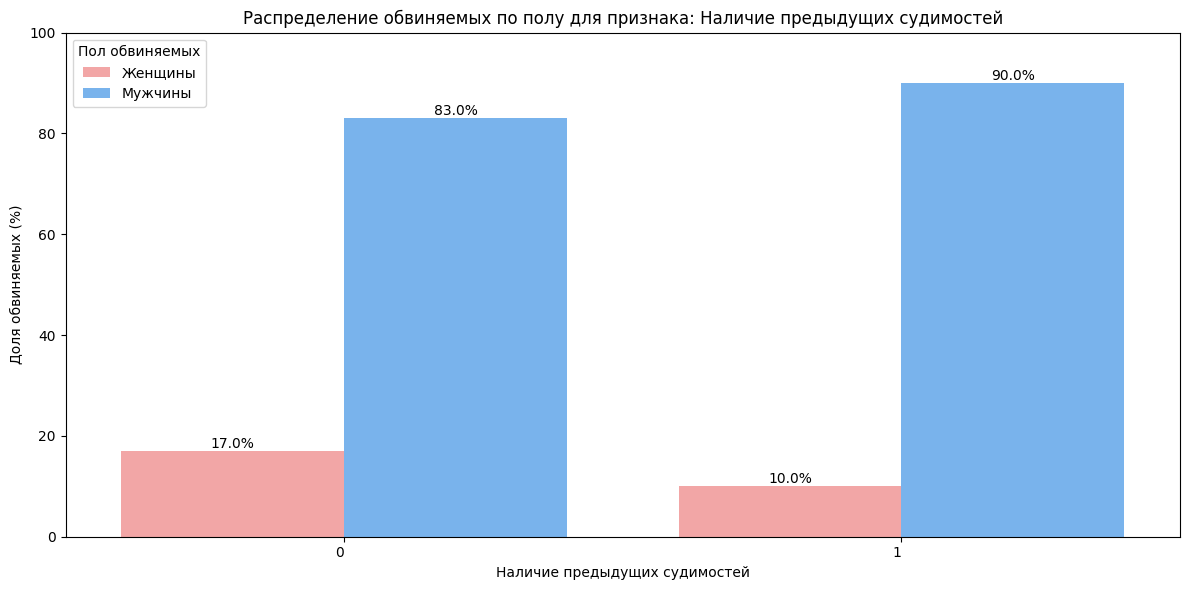

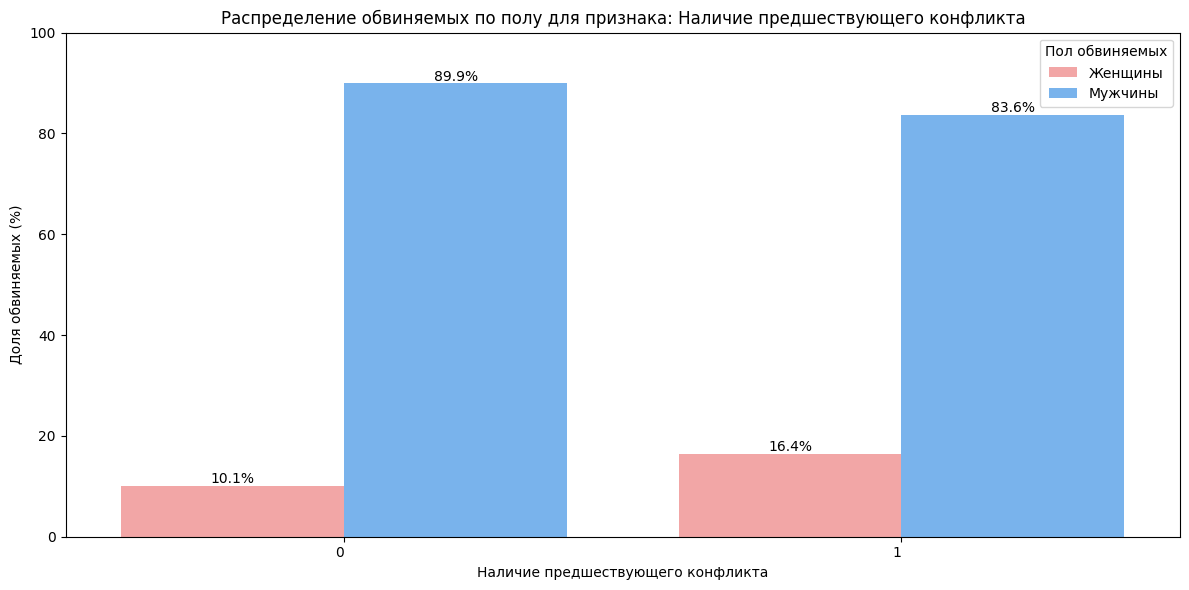

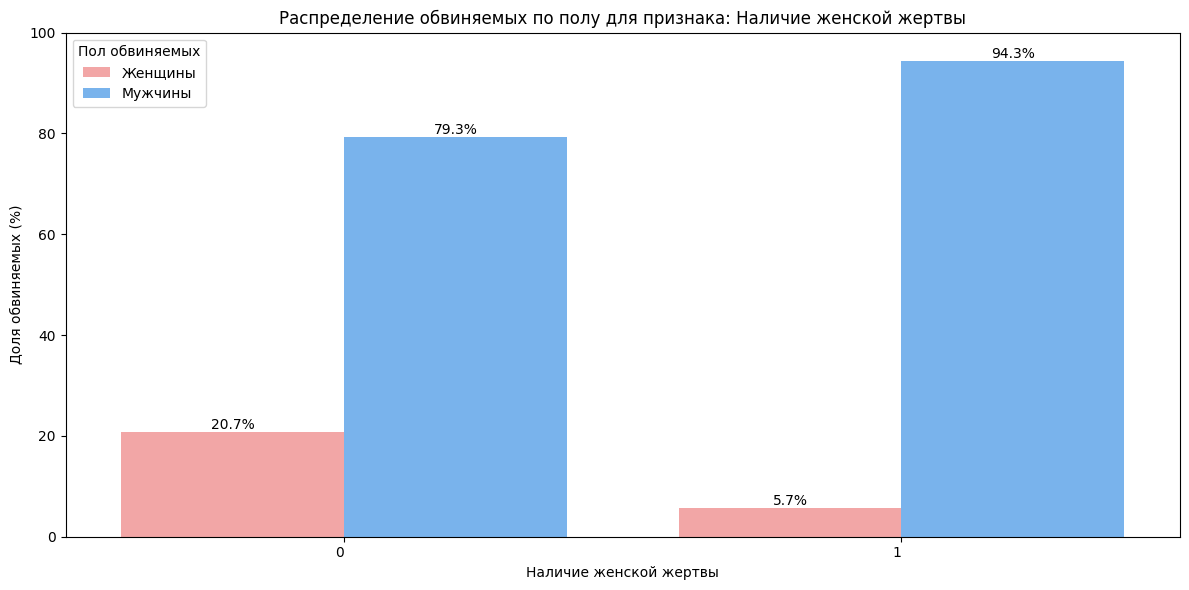

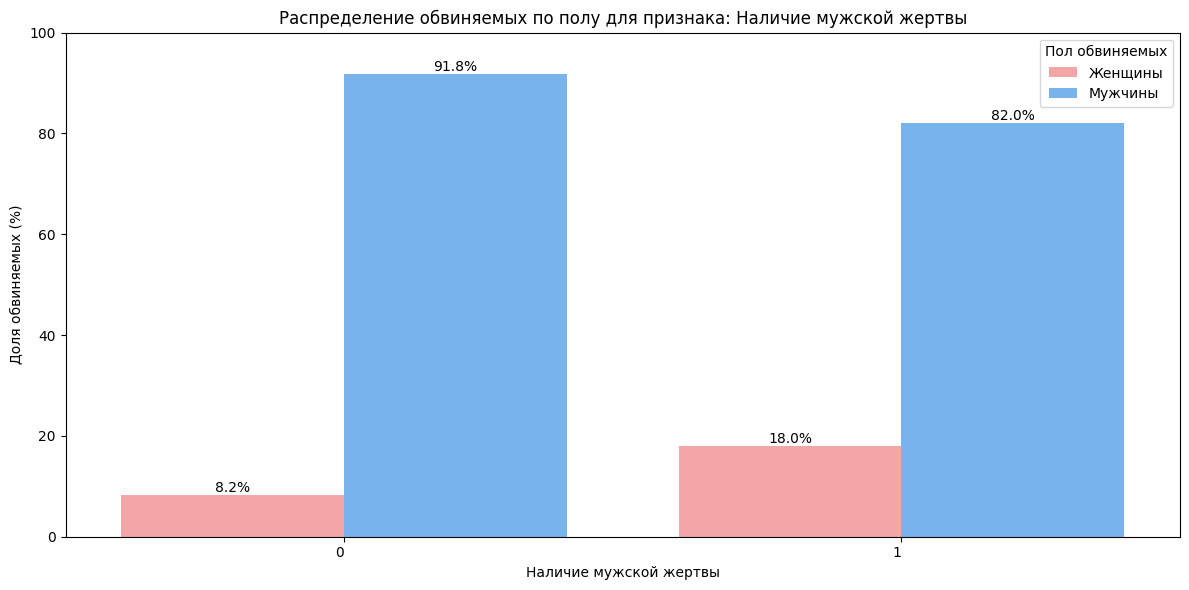

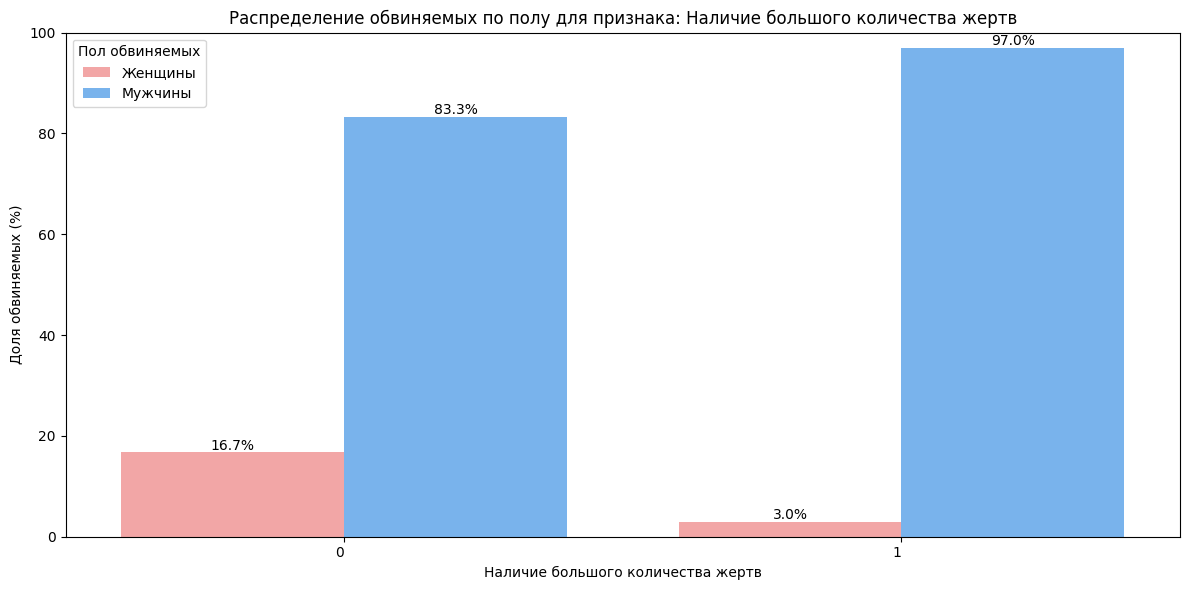

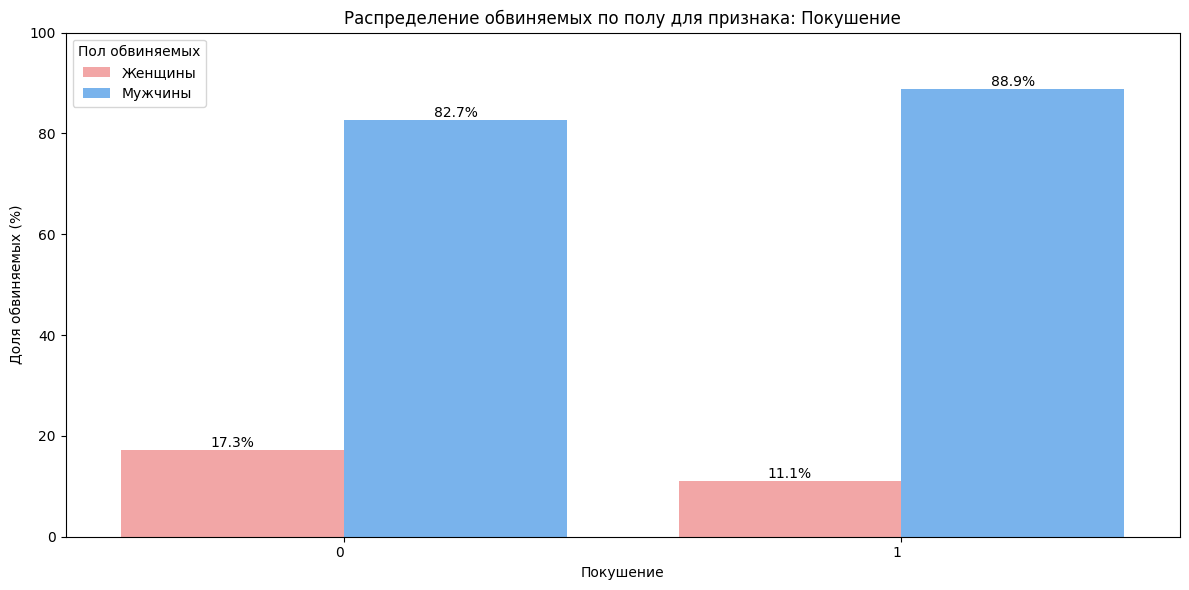

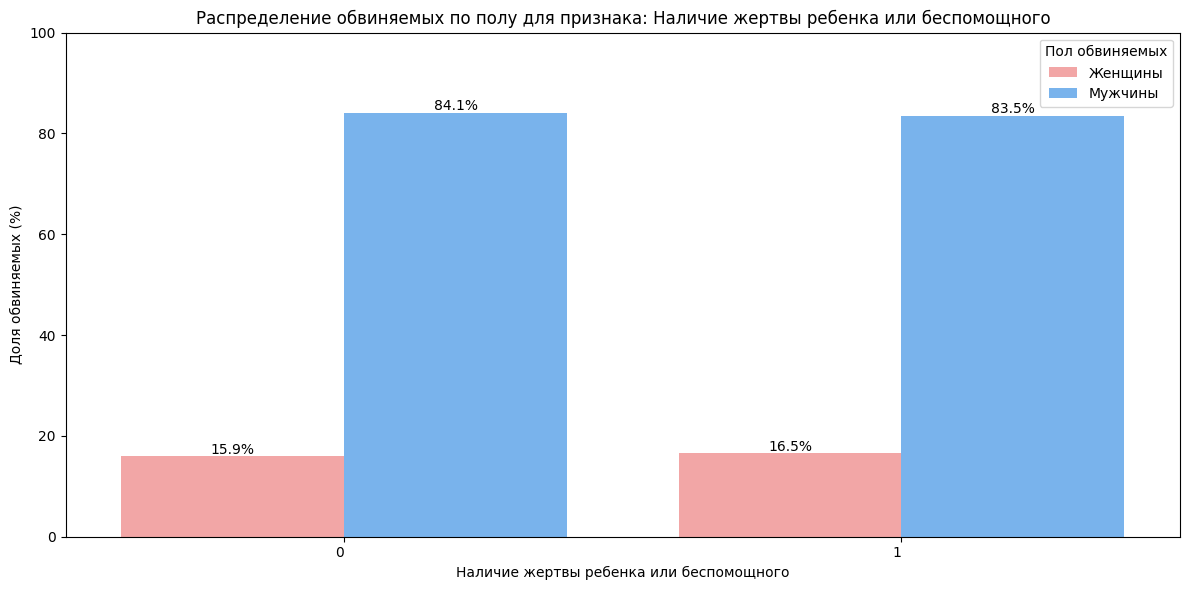

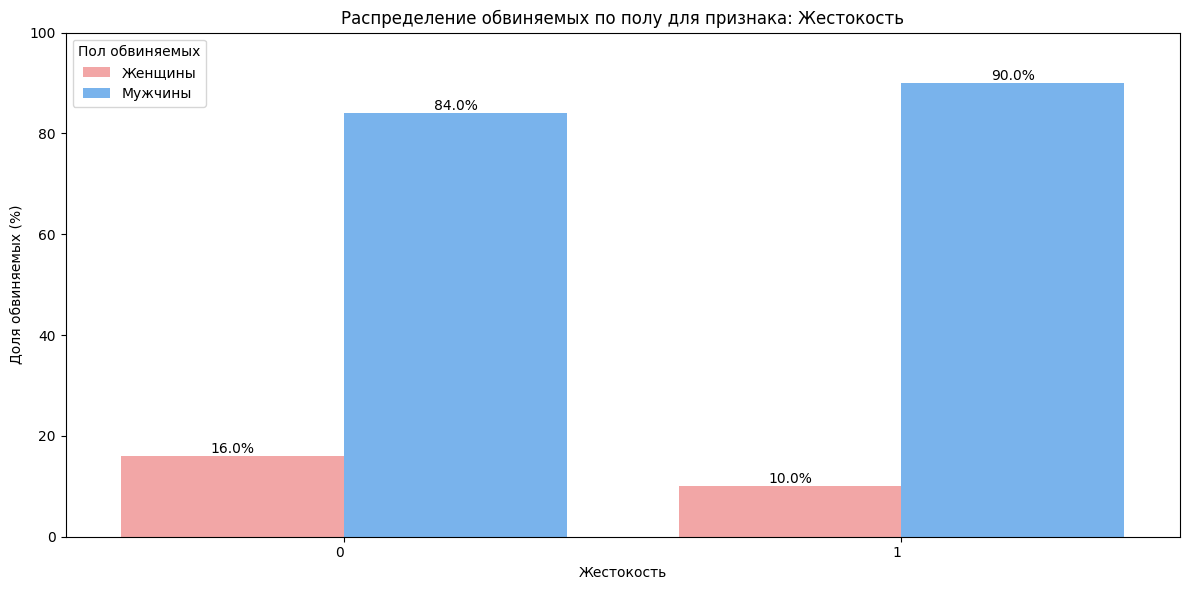

In [51]:
other = ['prior_convictions', 'precrime_argument', 'has_woman_victim', 'has_man_victim', 'many_victims', 'attempt', 'victim_child_or_helpless', 'cruel']
feature_names = {
    'alcohol': 'Употребление алкоголя',
    'precrime_argument': 'Наличие предшествующего конфликта',
    'prior_convictions': 'Наличие предыдущих судимостей',
    'location': 'Место преступления',
    'method': 'Способ совершения преступления',
    'motive': 'Мотив преступления',
    'has_woman_victim': 'Наличие женской жертвы',
    'has_man_victim': 'Наличие мужской жертвы',
    'many_victims': 'Наличие большого количества жертв',
    'attempt': 'Покушение',
    'victim_child_or_helpless' : 'Наличие жертвы ребенка или беспомощного',
    'cruel': 'Жестокость'
}
for feature in other:
    name = feature_names.get(feature, feature)
    plot_gender_share_by_feature(df, feature, feature_name=name)
    plt.savefig(f'gender_share_by_{feature}.png', dpi=300, bbox_inches='tight')
    plt.close()

## **CatBoost**

In [ ]:

y = df['gender_accused']
X = df.drop(['id', 'prison_term','judge', 'decision','gender_accused'], axis=1)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, 
    test_size=0.1, 
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, 
    test_size=0.1, 
    random_state=42
)

In [20]:
categorical= [ 'season', 'region_name', 'year']
other_features = [
    'prior_convictions', 'precrime_argument',
    'has_woman_victim', 'has_man_victim', 'many_victims', 'attempt',
    'victim_child_or_helpless', 'cruel', 'огнестрельное оружие',
    'тяжелые предметы', 'удушение', 'физическое воздействие',
    'холодное оружие', 'другой мотив', 'корысть', 'личная неприязнь',
    'ревность', 'другая локация', 'жилое помещение',
    'общественное место', 'общественный транспорт', 'подъезд и прилегающие зоны',
    'рабочая зона', 'уличное пространство'
]

numeric_features = ['prison_term']

selected_features = categorical + other_features + numeric_features


In [21]:
print(df.columns)

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'prison_term', 'many_victims', 'year', 'season', 'attempt',
       'victim_child_or_helpless', 'cruel', 'region_name', 'другое',
       'огнестрельное оружие', 'тяжелые предметы', 'удушение',
       'физическое воздействие', 'холодное оружие', 'алкоголь/наркотики',
       'аморальность', 'корысть', 'личная неприязнь', 'месть', 'насилие',
       'прочее', 'ревность', 'другое место', 'жилое помещение',
       'общественное место', 'общественный транспорт',
       'подъезд и прилегающие зоны', 'рабочая зона', 'уличное пространство'],
      dtype='object')


In [22]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def train_catboost_gender(X_train, y_train, X_val, y_val, X_test, y_test, categorical_features):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 500, 1500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
            'random_strength': trial.suggest_float('random_strength', 0.1, 10),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),
            'auto_class_weights': trial.suggest_categorical('auto_class_weights', [None, 'Balanced'])
        }
        model = CatBoostClassifier(
            **params,
            cat_features=categorical_features,
            verbose=0
        )
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50
        )
        val_pred = model.predict(X_val)
        f1 = f1_score(y_val, val_pred, average="weighted", zero_division=0)
        return f1

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    best_params = study.best_params
    print("\nЛУЧШИЕ ПАРАМЕТРЫ CatBoost для gender_accused:")
    print(best_params)

    final_model = CatBoostClassifier(
        **best_params,
        cat_features=categorical_features,
        verbose=100
    )
    final_model.fit(
        pd.concat([X_train, X_val]),
        pd.concat([y_train, y_val]),
        early_stopping_rounds=50
    )
    test_pred = final_model.predict(X_test)

    print("\nРезультаты CatBoost на тесте (gender_accused):")
    acc = accuracy_score(y_test, test_pred)
    precision, recall, f1 = precision_recall_fscore_support(
        y_test, test_pred, average="weighted", zero_division=0
    )[:3]
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    feature_importance = pd.DataFrame({
        'Feature': X_train.columns.tolist(),
        'Importance': final_model.get_feature_importance()
    }).sort_values(by='Importance', ascending=False)

    return final_model, feature_importance

X_cb_train, X_cb_val, X_cb_test = X_train, X_val, X_test

cat_model_gender, cat_importance_gender = train_catboost_gender(
    X_cb_train, y_train, X_cb_val, y_val, X_cb_test, y_test, categorical
)

print("\nCatBoost ТОП 10 признаков для предсказания gender_accused:")
print(cat_importance_gender.head(10))


[I 2025-04-29 11:00:29,230] A new study created in memory with name: no-name-09ab5758-6d36-4ea2-81dc-fec2f7387cc5


[I 2025-04-29 11:00:52,419] Trial 0 finished with value: 0.7399013515583861 and parameters: {'iterations': 1377, 'learning_rate': 0.06238220236123331, 'depth': 9, 'l2_leaf_reg': 0.09158761060286551, 'random_strength': 1.4199911187878609, 'bagging_temperature': 0.6287363269379144, 'grow_policy': 'Depthwise', 'auto_class_weights': 'Balanced'}. Best is trial 0 with value: 0.7399013515583861.
[I 2025-04-29 11:02:26,572] Trial 1 finished with value: 0.7374784961344715 and parameters: {'iterations': 1337, 'learning_rate': 0.012392092061877599, 'depth': 6, 'l2_leaf_reg': 0.015386763830133567, 'random_strength': 9.014046820579107, 'bagging_temperature': 0.7536861475235874, 'grow_policy': 'Depthwise', 'auto_class_weights': 'Balanced'}. Best is trial 0 with value: 0.7399013515583861.
[I 2025-04-29 11:04:26,445] Trial 2 finished with value: 0.7406151994507764 and parameters: {'iterations': 867, 'learning_rate': 0.038104529723469574, 'depth': 9, 'l2_leaf_reg': 0.002480419095050315, 'random_strengt


ЛУЧШИЕ ПАРАМЕТРЫ CatBoost для gender_accused:
{'iterations': 1106, 'learning_rate': 0.17302788337037284, 'depth': 4, 'l2_leaf_reg': 0.9967091795993915, 'random_strength': 3.4137498783162803, 'bagging_temperature': 0.995986981760043, 'grow_policy': 'Lossguide', 'auto_class_weights': None}
0:	learn: 0.5895317	total: 97.6ms	remaining: 1m 47s
100:	learn: 0.3556122	total: 13.8s	remaining: 2m 17s
200:	learn: 0.3495722	total: 28.8s	remaining: 2m 9s
300:	learn: 0.3454889	total: 43.4s	remaining: 1m 56s
400:	learn: 0.3412449	total: 58.2s	remaining: 1m 42s
500:	learn: 0.3379031	total: 1m 12s	remaining: 1m 27s
600:	learn: 0.3347209	total: 1m 26s	remaining: 1m 13s
700:	learn: 0.3321599	total: 1m 41s	remaining: 58.6s
800:	learn: 0.3297603	total: 1m 55s	remaining: 44s
900:	learn: 0.3279645	total: 2m 9s	remaining: 29.5s
1000:	learn: 0.3255406	total: 2m 24s	remaining: 15.2s
1100:	learn: 0.3230423	total: 2m 40s	remaining: 731ms
1105:	learn: 0.3229836	total: 2m 41s	remaining: 0us

Результаты CatBoost на

C:\Users\tikho\AppData\Local\Temp\ipykernel_16620\3265202728.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature', palette='viridis')


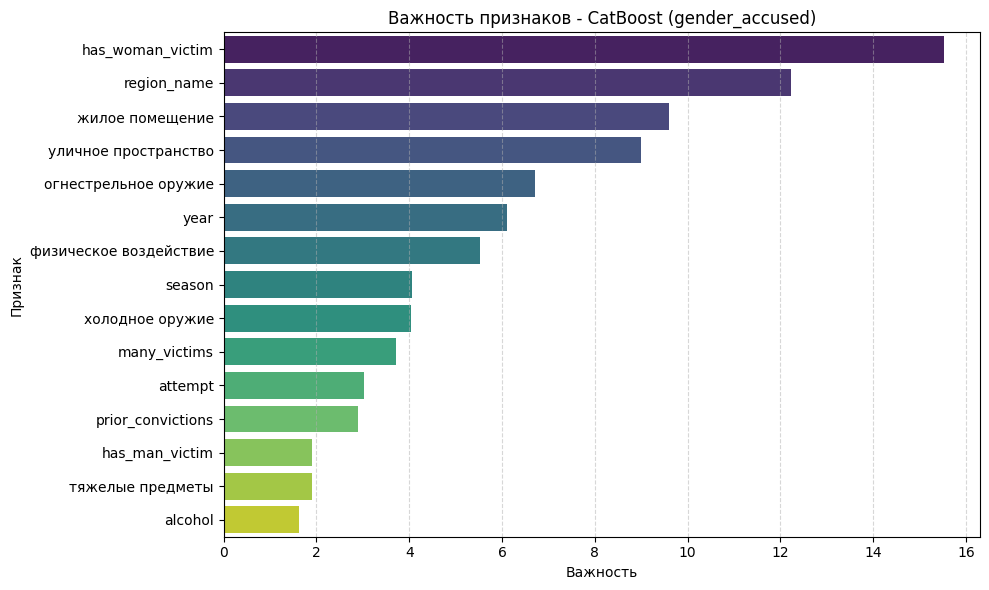


Топ признаков для предсказания gender_accused:
                   Feature  Importance
3         has_woman_victim   15.524919
11             region_name   12.219399
27         жилое помещение    9.606777
32    уличное пространство    8.993860
13    огнестрельное оружие    6.710347
6                     year    6.115018
16  физическое воздействие    5.527870
7                   season    4.050398
17         холодное оружие    4.044877
5             many_victims    3.719405


In [24]:
def plot_feature_importance(model, feature_names, model_name="CatBoost (gender_accused)"):
    importance = model.get_feature_importance()
    feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    feature_importance = feature_importance.sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance.head(15), x='Importance', y='Feature', palette='viridis')
    plt.title(f'Важность признаков - {model_name}')
    plt.xlabel('Важность')
    plt.ylabel('Признак')
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return feature_importance

catboost_importance_gender = plot_feature_importance(cat_model_gender, X_cb_train.columns)
print("\nТоп признаков для предсказания gender_accused:")
print(catboost_importance_gender.head(10))


In [68]:
print(catboost_importance_gender.tail(15))

                       Feature  Importance
9     victim_child_or_helpless    1.026576
10                       cruel    0.951289
12                      другое    0.875345
31                рабочая зона    0.850801
25                    ревность    0.845812
26                другое место    0.816402
15                    удушение    0.811530
30  подъезд и прилегающие зоны    0.696344
24                      прочее    0.482153
21            личная неприязнь    0.397872
22                       месть    0.220266
19                аморальность    0.078779
23                     насилие    0.038128
29      общественный транспорт    0.032459
18          алкоголь/наркотики    0.008573


In [73]:
df.columns

Index(['id', 'judge', 'decision', 'gender_accused', 'prior_convictions',
       'alcohol', 'precrime_argument', 'has_woman_victim', 'has_man_victim',
       'prison_term', 'many_victims', 'year', 'season', 'attempt',
       'victim_child_or_helpless', 'cruel', 'region_name', 'другое',
       'огнестрельное оружие', 'тяжелые предметы', 'удушение',
       'физическое воздействие', 'холодное оружие', 'алкоголь/наркотики',
       'аморальность', 'корысть', 'личная неприязнь', 'месть', 'насилие',
       'прочее', 'ревность', 'другое', 'жилое помещение', 'общественное место',
       'общественный транспорт', 'подъезд и прилегающие зоны', 'рабочая зона',
       'уличное пространство'],
      dtype='object')

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
categorical= [ 'season', 'region_name', 'year']
other_features = [
    'prior_convictions', 'precrime_argument',
    'has_woman_victim', 'has_man_victim', 'many_victims', 'attempt',
    'victim_child_or_helpless', 'огнестрельное оружие',
    'тяжелые предметы', 'физическое воздействие',
    'холодное оружие', 'другой мотив', 'корысть', 'личная неприязнь',
    'ревность', 'жилое помещение',
    'общественное место',
    'рабочая зона', 'уличное пространство'
]

#numeric_features = ['prison_term']

selected_features = categorical + other_features

y = df['gender_accused']
X = df.drop([ 'decision', 'gender_accused','judge','алкоголь/наркотики','общественный транспорт','насилие','аморальность', 'другое','удушение', 'подъезд и прилегающие зоны','месть','cruel','id'], axis=1)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, 
    test_size=0.1, 
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, 
    test_size=0.1, 
    random_state=42
)

def train_catboost_gender(X_train, y_train, X_val, y_val, X_test, y_test, categorical_features):
    def objective(trial):
        params = {
            'iterations': trial.suggest_int('iterations', 500, 1500),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10, log=True),
            'random_strength': trial.suggest_float('random_strength', 0.1, 10),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
            'grow_policy': trial.suggest_categorical('grow_policy', ['SymmetricTree', 'Depthwise', 'Lossguide']),
            'auto_class_weights': trial.suggest_categorical('auto_class_weights', [None, 'Balanced'])
        }
        model = CatBoostClassifier(
            **params,
            cat_features=categorical_features,
            verbose=0
        )
        model.fit(
            X_train, y_train,
            eval_set=(X_val, y_val),
            early_stopping_rounds=50
        )
        val_pred = model.predict(X_val)
        f1 = f1_score(y_val, val_pred, average="weighted", zero_division=0)
        return f1

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    best_params = study.best_params
    print("\nЛУЧШИЕ ПАРАМЕТРЫ CatBoost для gender_accused:")
    print(best_params)

    final_model = CatBoostClassifier(
        **best_params,
        cat_features=categorical_features,
        verbose=100
    )
    final_model.fit(
        pd.concat([X_train, X_val]),
        pd.concat([y_train, y_val]),
        early_stopping_rounds=50
    )
    test_pred = final_model.predict(X_test)

    print("\nРезультаты CatBoost на тесте (gender_accused):")
    acc = accuracy_score(y_test, test_pred)
    precision, recall, f1 = precision_recall_fscore_support(
        y_test, test_pred, average="weighted", zero_division=0
    )[:3]
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")

    feature_importance = pd.DataFrame({
        'Feature': X_train.columns.tolist(),
        'Importance': final_model.get_feature_importance()
    }).sort_values(by='Importance', ascending=False)

    return final_model, feature_importance

X_cb_train, X_cb_val, X_cb_test = X_train, X_val, X_test

cat_model_gender, cat_importance_gender = train_catboost_gender(
    X_cb_train, y_train, X_cb_val, y_val, X_cb_test, y_test, categorical
)

print("\nCatBoost ТОП 10 признаков для предсказания gender_accused:")
print(cat_importance_gender.head(10))


[I 2025-04-29 21:54:11,319] A new study created in memory with name: no-name-389af55e-53e9-4a4e-bd17-cb4b79c653c0
[I 2025-04-29 21:58:20,889] Trial 0 finished with value: 0.8373359110320053 and parameters: {'iterations': 652, 'learning_rate': 0.02627706075581314, 'depth': 7, 'l2_leaf_reg': 0.5562922301933695, 'random_strength': 7.292358883102638, 'bagging_temperature': 0.23396400025262287, 'grow_policy': 'Lossguide', 'auto_class_weights': None}. Best is trial 0 with value: 0.8373359110320053.
[I 2025-04-29 21:58:54,014] Trial 1 finished with value: 0.7947928632579636 and parameters: {'iterations': 1359, 'learning_rate': 0.04494624409327235, 'depth': 7, 'l2_leaf_reg': 2.3936275006159073, 'random_strength': 0.6779762425929137, 'bagging_temperature': 0.4680286158572672, 'grow_policy': 'Depthwise', 'auto_class_weights': 'Balanced'}. Best is trial 0 with value: 0.8373359110320053.
[I 2025-04-29 22:01:57,228] Trial 2 finished with value: 0.8387926557370222 and parameters: {'iterations': 726,


ЛУЧШИЕ ПАРАМЕТРЫ CatBoost для gender_accused:
{'iterations': 1100, 'learning_rate': 0.10451385273825342, 'depth': 6, 'l2_leaf_reg': 0.0010208804736501305, 'random_strength': 0.650575606319354, 'bagging_temperature': 0.2676752978273643, 'grow_policy': 'SymmetricTree', 'auto_class_weights': None}
0:	learn: 0.6061605	total: 110ms	remaining: 2m
100:	learn: 0.3121306	total: 10.3s	remaining: 1m 41s
200:	learn: 0.2964959	total: 19.2s	remaining: 1m 25s
300:	learn: 0.2838991	total: 29.3s	remaining: 1m 17s
400:	learn: 0.2737416	total: 38.4s	remaining: 1m 6s
500:	learn: 0.2645240	total: 48.3s	remaining: 57.7s
600:	learn: 0.2553904	total: 57s	remaining: 47.3s
700:	learn: 0.2465538	total: 1m 5s	remaining: 37.2s
800:	learn: 0.2385980	total: 1m 13s	remaining: 27.5s
900:	learn: 0.2310062	total: 1m 22s	remaining: 18.2s
1000:	learn: 0.2239726	total: 1m 31s	remaining: 9.02s
1099:	learn: 0.2173261	total: 1m 40s	remaining: 0us

Результаты CatBoost на тесте (gender_accused):
Accuracy: 0.8584
Precision: 0.8

In [16]:
import joblib
joblib.dump(cat_model_gender, 'catboost_model_gender.joblib')

['catboost_model_gender.joblib']

## **RandomForest**

In [40]:
column_transformer = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical)
])

X_train_rf = column_transformer.fit_transform(X_train)
X_val_rf = column_transformer.transform(X_val)
X_test_rf = column_transformer.transform(X_test)
feature_names_rf = column_transformer.get_feature_names_out()

def train_rf_classifier(X_train, y_train, X_val, y_val, X_test, y_test):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2',None]),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestClassifier(**params)
        model.fit(X_train, y_train)
        val_preds = model.predict(X_val)
        f1 = precision_recall_fscore_support(y_val, val_preds, average='weighted', zero_division=0)[2]
        return f1

    study = create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    print("\n Лучшие параметры Random Forest:")
    for k, v in study.best_params.items():
        print(f"{k}: {v}")

    model = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
    model.fit(np.vstack([X_train, X_val]), np.hstack([y_train, y_val]))
    test_preds = model.predict(X_test)

    acc = accuracy_score(y_test, test_preds)
    prec, rec, f1 = precision_recall_fscore_support(y_test, test_preds, average='weighted', zero_division=0)[:3]

    print("\n Метрики на тесте:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")

    importance_df = pd.DataFrame({
        'Feature': feature_names_rf,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    return model, importance_df

rf_model_gender, rf_importance_gender = train_rf_classifier(
    X_train_rf, y_train, X_val_rf, y_val, X_test_rf, y_test
)

print("\n Топ-10 признаков для Random Forest:")
print(rf_importance_gender.head(10))


[I 2025-04-29 12:20:27,218] A new study created in memory with name: no-name-f15d2306-56c5-4f2a-8f8f-0240c93bd8de


[I 2025-04-29 12:20:30,182] Trial 0 finished with value: 0.7595150131210833 and parameters: {'n_estimators': 138, 'max_depth': 15, 'min_samples_split': 4, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': False}. Best is trial 0 with value: 0.7595150131210833.
[I 2025-04-29 12:20:38,039] Trial 1 finished with value: 0.7595150131210833 and parameters: {'n_estimators': 466, 'max_depth': 30, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.7595150131210833.
[I 2025-04-29 12:22:03,426] Trial 2 finished with value: 0.7608436719771273 and parameters: {'n_estimators': 271, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': False}. Best is trial 2 with value: 0.7608436719771273.
[I 2025-04-29 12:22:14,978] Trial 3 finished with value: 0.7595150131210833 and parameters: {'n_estimators': 649, 'max_depth': 16, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_feature


 Лучшие параметры Random Forest:
n_estimators: 846
max_depth: 27
min_samples_split: 10
min_samples_leaf: 1
max_features: None
bootstrap: False

 Метрики на тесте:
Accuracy:  0.8366
Precision: 0.7280
Recall:    0.8366
F1-score:  0.7677

 Топ-10 признаков для Random Forest:
               Feature  Importance
3    cat__season_Осень    0.088512
2     cat__season_Лето    0.082071
1     cat__season_Зима    0.081266
95      cat__year_2017    0.077369
0    cat__season_Весна    0.077137
97      cat__year_2019    0.070348
101     cat__year_2023    0.054268
98      cat__year_2020    0.045696
93      cat__year_2015    0.044190
99      cat__year_2021    0.041403


In [52]:
def group_top_categories(df, column, top_n=10, other_label='другое'):
    top_categories = df[column].value_counts().nlargest(top_n).index
    
    df[column] = df[column].apply(lambda x: x if x in top_categories else other_label)
    return df
df = group_top_categories(df, 'judge', top_n=8, other_label='другое судьи')
df = group_top_categories(df, 'region_name', top_n=8, other_label='другое регионы')
df = group_top_categories(df, 'year', top_n=8, other_label='другое год')
df['year'] = df['year'].astype(str)
df['year'].value_counts()

year
2016          6090
2017          5894
2018          4935
2020          4446
2021          4293
2019          4172
2022          4031
2023          2380
другое год    1328
Name: count, dtype: int64

In [53]:
column_transformer = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical)
])

X_train_rf = column_transformer.fit_transform(X_train)
X_val_rf = column_transformer.transform(X_val)
X_test_rf = column_transformer.transform(X_test)
feature_names_rf = column_transformer.get_feature_names_out()

def train_rf_classifier(X_train, y_train, X_val, y_val, X_test, y_test):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
            'max_depth': trial.suggest_int('max_depth', 3, 30),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2',None]),
            'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
            'random_state': 42,
            'n_jobs': -1
        }
        model = RandomForestClassifier(**params)
        model.fit(X_train, y_train)
        val_preds = model.predict(X_val)
        f1 = precision_recall_fscore_support(y_val, val_preds, average='weighted', zero_division=0)[2]
        return f1

    study = create_study(direction='maximize')
    study.optimize(objective, n_trials=20)

    print("\n Лучшие параметры Random Forest:")
    for k, v in study.best_params.items():
        print(f"{k}: {v}")

    model = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
    model.fit(np.vstack([X_train, X_val]), np.hstack([y_train, y_val]))
    test_preds = model.predict(X_test)

    acc = accuracy_score(y_test, test_preds)
    prec, rec, f1 = precision_recall_fscore_support(y_test, test_preds, average='weighted', zero_division=0)[:3]

    print("\n Метрики на тесте:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1-score:  {f1:.4f}")

    importance_df = pd.DataFrame({
        'Feature': feature_names_rf,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    return model, importance_df

rf_model_gender, rf_importance_gender = train_rf_classifier(
    X_train_rf, y_train, X_val_rf, y_val, X_test_rf, y_test
)

print("\n Топ-10 признаков для Random Forest:")
print(rf_importance_gender.head(10))


[I 2025-04-29 14:25:00,404] A new study created in memory with name: no-name-f8314607-f9f0-4b1b-bddc-643602e41318
[I 2025-04-29 14:25:18,511] Trial 0 finished with value: 0.7595150131210833 and parameters: {'n_estimators': 994, 'max_depth': 16, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': False}. Best is trial 0 with value: 0.7595150131210833.
[I 2025-04-29 14:25:24,939] Trial 1 finished with value: 0.7595150131210833 and parameters: {'n_estimators': 735, 'max_depth': 11, 'min_samples_split': 3, 'min_samples_leaf': 10, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.7595150131210833.
[I 2025-04-29 14:27:53,765] Trial 2 finished with value: 0.7607896449798311 and parameters: {'n_estimators': 942, 'max_depth': 29, 'min_samples_split': 4, 'min_samples_leaf': 3, 'max_features': None, 'bootstrap': True}. Best is trial 2 with value: 0.7607896449798311.
[I 2025-04-29 14:31:54,405] Trial 3 finished with value: 0.7593683478467755 


 Лучшие параметры Random Forest:
n_estimators: 942
max_depth: 29
min_samples_split: 4
min_samples_leaf: 3
max_features: None
bootstrap: True

 Метрики на тесте:
Accuracy:  0.8406
Precision: 0.7473
Recall:    0.8406
F1-score:  0.7687

 Топ-10 признаков для Random Forest:
              Feature  Importance
1    cat__season_Зима    0.080525
2    cat__season_Лето    0.078164
0   cat__season_Весна    0.076797
3   cat__season_Осень    0.074110
95     cat__year_2017    0.056185
94     cat__year_2016    0.050487
98     cat__year_2020    0.047054
97     cat__year_2019    0.046020
99     cat__year_2021    0.045660
96     cat__year_2018    0.045552
